In [7]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 基础配置
SEED = 42
WAVE_LEN = 116
SPLIT_DIR = r'D:\Project_Github\Indo-Pacific-humpback-dolphin\06_DataSplit'

def apply_zscore_norm(X):
    """
    对矩阵 X 中的每一个样本(行)独立进行 Z-Score 归一化
    """
    # 计算每一行的均值和标准差
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)
    
    # 防止除以 0
    std[std == 0] = 1.0
    
    return (X - mean) / std

def load_data_from_csv(csv_path, target_length=116):
    """从CSV文件中读取路径并加载音频波形"""
    df = pd.read_csv(csv_path)
    X = []
    y = []
    
    desc = f"Loading {os.path.basename(csv_path)}"
    # 显示单个CSV加载的进度条
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc, leave=False):
        file_path = row['path']
        label = row['label']
        
        try:
            if not os.path.exists(file_path):
                continue
            sig, sr = librosa.load(file_path, sr=None)
            if len(sig) > target_length:
                sig = sig[:target_length]
            else:
                sig = np.pad(sig, (0, max(0, target_length - len(sig))), 'constant')
            X.append(sig)
            y.append(label)
        except Exception:
            continue
            
    return np.array(X), np.array(y)

print("Chico, 环境与函数准备就绪。")

Chico, 环境与函数准备就绪。


In [8]:
fold_results = []
final_model = None 

print("开始执行 10 折交叉验证循环...")
# 显示 10 折总进度条
for i in tqdm(range(1, 11), desc="Total 10-Fold Progress"):
    train_csv = os.path.join(SPLIT_DIR, f'fold_{i}_train.csv')
    val_csv = os.path.join(SPLIT_DIR, f'fold_{i}_val.csv')
    
    # 加载原始数据
    X_train_raw, y_train = load_data_from_csv(train_csv, target_length=WAVE_LEN)
    X_val_raw, y_val = load_data_from_csv(val_csv, target_length=WAVE_LEN)
    
    # 样本级 Z-Score 归一化预处理
    X_train = apply_zscore_norm(X_train_raw)
    X_val = apply_zscore_norm(X_val_raw)
    
    # 定义并训练模型
    svm_pipe = Pipeline([
        ('scaler', StandardScaler()), # 特征维度的标准化
        ('svm', SVC(kernel='rbf', C=1.0, random_state=SEED))
    ])
    
    svm_pipe.fit(X_train, y_train)
    
    # 预测并记录结果
    val_preds = svm_pipe.predict(X_val)
    acc = accuracy_score(y_val, val_preds)
    fold_results.append(acc)
    
    if i == 10:
        final_model = svm_pipe

print(f"\nChico, 10折交叉验证完成！平均准确率: {np.mean(fold_results):.4f} (+/- {np.std(fold_results):.4f})")

开始执行 10 折交叉验证循环...


Total 10-Fold Progress: 100%|██████████| 10/10 [02:44<00:00, 16.42s/it]


Chico, 10折交叉验证完成！平均准确率: 0.9616 (+/- 0.0258)


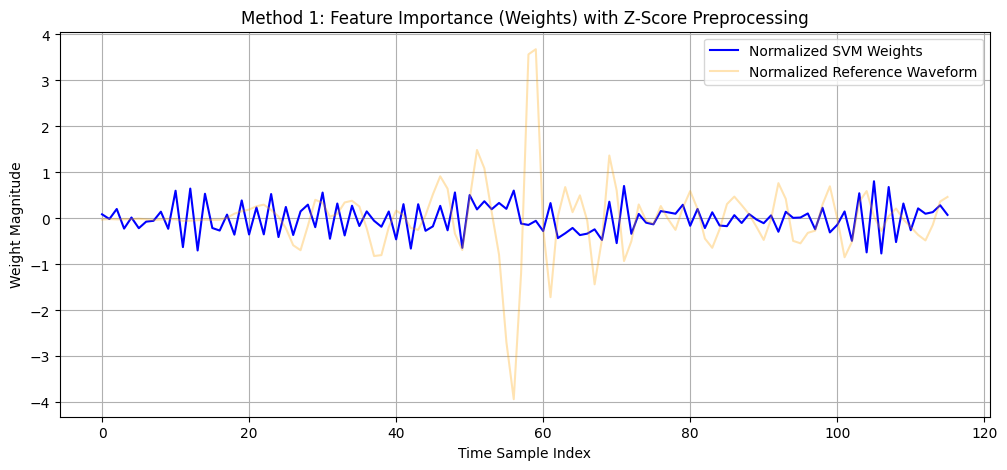

In [9]:
# 加载测试集并预处理
test_csv = os.path.join(SPLIT_DIR, 'test_set.csv')
X_test_raw, y_test = load_data_from_csv(test_csv, target_length=WAVE_LEN)
X_test = apply_zscore_norm(X_test_raw)

# 训练线性核模型用于权重可视化
lin_svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', random_state=SEED))
])
lin_svm_pipe.fit(X_test, y_test)

# 获取并绘制权重
weights = lin_svm_pipe.named_steps['svm'].coef_[0]

plt.figure(figsize=(12, 5))
plt.plot(weights, label='Normalized SVM Weights', color='blue')
sample_idx = np.where(y_test == 1)[0][0]
plt.plot(X_test[sample_idx] * np.max(np.abs(weights)), alpha=0.3, color='orange', label='Normalized Reference Waveform')
plt.title("Method 1: Feature Importance (Weights) with Z-Score Preprocessing")
plt.xlabel("Time Sample Index")
plt.ylabel("Weight Magnitude")
plt.legend()
plt.grid(True)
plt.show()

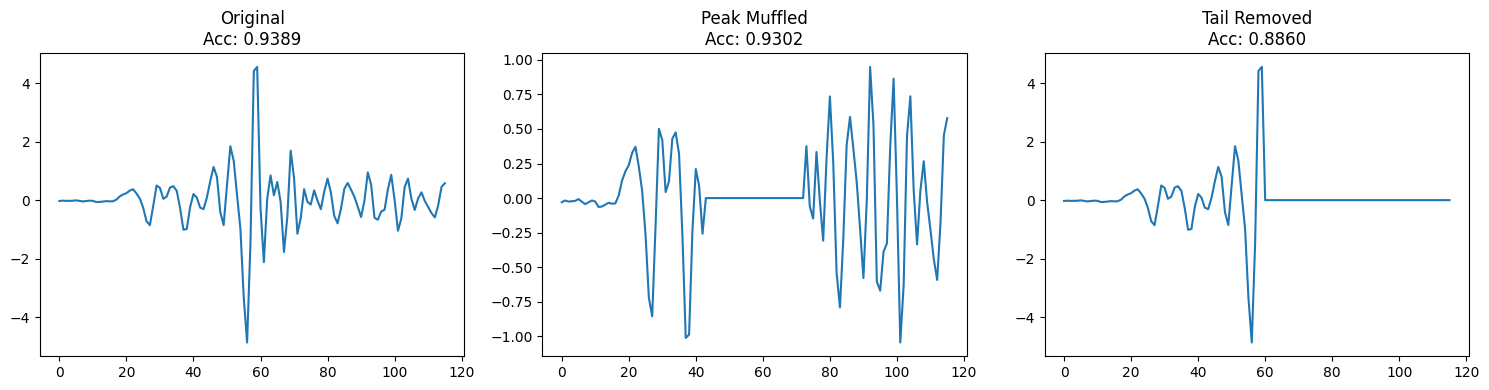

In [10]:
def run_ablation_zscore(X_data, y_data, model_pipe, mode='original'):
    X_mod = X_data.copy()
    mid = WAVE_LEN // 2
    
    if mode == 'kill_peak':
        X_mod[:, mid-15:mid+15] = 0
        label = "Peak Muffled"
    elif mode == 'kill_tail':
        X_mod[:, 60:] = 0
        label = "Tail Removed"
    else:
        label = "Original"
        
    # 注意：消融后不再重新计算 Z-Score，以观察模型在缺失部分特征时的反应
    preds = model_pipe.predict(X_mod)
    acc = accuracy_score(y_data, preds)
    return label, acc, X_mod[0]

modes = ['original', 'kill_peak', 'kill_tail']
plt.figure(figsize=(15, 4))
for i, m in enumerate(modes):
    name, acc, wave = run_ablation_zscore(X_test, y_test, final_model, mode=m)
    plt.subplot(1, 3, i+1)
    plt.plot(wave)
    plt.title(f"{name}\nAcc: {acc:.4f}")

plt.tight_layout()
plt.show()

In [15]:
import re
import os

test_preds = final_model.predict(X_test)

# 1. 定义输出路径
OUTPUT_DIR_ERROR = r'D:\Project_Github\Indo-Pacific-humpback-dolphin\07_PreTrial'
if not os.path.exists(OUTPUT_DIR_ERROR):
    os.makedirs(OUTPUT_DIR_ERROR)

# 2. 重新读取测试集原始路径（确保与 y_test 索引严格对应）
test_df_orig = pd.read_csv(os.path.join(SPLIT_DIR, 'test_set.csv'))

# 3. 找出预测错误的索引
misclassified_indices = np.where(y_test != test_preds)[0]

error_list = []

print(f"Chico, 正在解析 {len(misclassified_indices)} 个错误样本并保存至 07_PreTrail...")

for idx in misclassified_indices:
    path = test_df_orig.iloc[idx]['path']
    true_label = "Click" if y_test[idx] == 1 else "Noise"
    pred_label = "Click" if test_preds[idx] == 1 else "Noise"
    
    filename = os.path.basename(path)
    
    # 初始化字段
    ori_file = "N/A"
    train_num = "N/A"
    pulse_num = "N/A"
    
    if "PulseTrain_" in path:
        # 正样本逻辑：从路径和文件名提取
        # 路径示例: .../PulseTrain_001/Pulse_1.wav
        train_match = re.search(r'PulseTrain_(\d+)', path)
        pulse_match = re.search(r'Pulse_(\d+)', filename)
        if train_match: train_num = train_match.group(1)
        if pulse_match: pulse_num = pulse_match.group(1)
        ori_file = "Positive_Pool" # 正样本的OriFile建议查阅原始ClickTrains.csv
    else:
        # 负样本逻辑：从文件名提取
        # 文件名示例: FalseClick_Ori_Recording_01_0001.wav
        neg_match = re.search(r'Ori_Recording_(\d+)_(\d+)', filename)
        if neg_match:
            ori_file = neg_match.group(1)
            pulse_num = neg_match.group(2)
            train_num = "None(Noise)"

    error_list.append({
        'Ori_File_Num': ori_file,
        'Train_Num': train_num,
        'Pulse_Num': pulse_num,
        'True_Label': true_label,
        'Predicted_Label': pred_label,
        'Full_Path': path
    })

# 4. 生成 DataFrame 并保存
error_df = pd.DataFrame(error_list)
error_csv_path = os.path.join(OUTPUT_DIR_ERROR, 'misclassified_samples.csv')
error_df.to_csv(error_csv_path, index=False, encoding='utf-8-sig')

print(f"Chico, 错误记录已生成：\n路径: {error_csv_path}")
print(f"包含列: Ori_File_Num, Train_Num, Pulse_Num, True_Label, Predicted_Label")

# 展示前5行结果
error_df.head()

Chico, 正在解析 112 个错误样本并保存至 07_PreTrail...
Chico, 错误记录已生成：
路径: D:\Project_Github\Indo-Pacific-humpback-dolphin\07_PreTrial\misclassified_samples.csv
包含列: Ori_File_Num, Train_Num, Pulse_Num, True_Label, Predicted_Label


,Ori_File_Num,Train_Num,Pulse_Num,True_Label,Predicted_Label,Full_Path
0,Positive_Pool,257,1,Click,Noise,D:\Project_Github\Indo-Pacific-humpback-dolphi...
1,Positive_Pool,257,2,Click,Noise,D:\Project_Github\Indo-Pacific-humpback-dolphi...
2,Positive_Pool,257,3,Click,Noise,D:\Project_Github\Indo-Pacific-humpback-dolphi...
3,Positive_Pool,257,4,Click,Noise,D:\Project_Github\Indo-Pacific-humpback-dolphi...
4,Positive_Pool,257,6,Click,Noise,D:\Project_Github\Indo-Pacific-humpback-dolphi...


In [17]:
import re
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

# 1. 定义路径
OUTPUT_DIR_ERROR = r'D:\Project_Github\Indo-Pacific-humpback-dolphin\07_PreTrial'
WAVEFORM_DIR = os.path.join(OUTPUT_DIR_ERROR, 'error_waveforms')

if not os.path.exists(WAVEFORM_DIR):
    os.makedirs(WAVEFORM_DIR)

# 2. 重新获取测试集原始路径（确保索引对应）
test_df_orig = pd.read_csv(os.path.join(SPLIT_DIR, 'test_set.csv'))

# 3. 找出预测错误的索引
misclassified_indices = np.where(y_test != test_preds)[0]

error_list = []

print(f"Chico, 正在处理 {len(misclassified_indices)} 个错误样本...")

# 使用 tqdm 显示绘图进度
for idx in tqdm(misclassified_indices, desc="Plotting Error Waveforms"):
    path = test_df_orig.iloc[idx]['path']
    true_label_str = "Click" if y_test[idx] == 1 else "Noise"
    pred_label_str = "Click" if test_preds[idx] == 1 else "Noise"
    
    filename_src = os.path.basename(path)
    
    # 解析元数据用于命名和记录
    ori_file = "N/A"
    train_num = "N/A"
    pulse_num = "N/A"
    
    if "PulseTrain_" in path:
        train_match = re.search(r'PulseTrain_(\d+)', path)
        pulse_match = re.search(r'Pulse_(\d+)', filename_src)
        if train_match: train_num = train_match.group(1)
        if pulse_match: pulse_num = pulse_match.group(1)
        ori_file = "PosPool"
    else:
        neg_match = re.search(r'Ori_Recording_(\d+)_(\d+)', filename_src)
        if neg_match:
            ori_file = neg_match.group(1)
            pulse_num = neg_match.group(2)
            train_num = "Noise"

    # --- 绘图部分 ---
    # 获取已经 Z-Score 归一化后的波形 (在 Cell 3 中已处理)
    waveform = X_test[idx]
    
    plt.figure(figsize=(8, 4))
    plt.plot(waveform, color='red' if y_test[idx] == 0 else 'green')
    plt.title(f"True: {true_label_str} | Pred: {pred_label_str}\nFile: {ori_file} | Train: {train_num} | Pulse: {pulse_num}")
    plt.xlabel("Sample Index")
    plt.ylabel("Z-Score Amplitude")
    plt.grid(True, alpha=0.3)
    
    # 构造保存文件名
    save_name = f"Err_{idx}_T-{true_label_str}_P-{pred_label_str}_F{ori_file}_P{pulse_num}.png"
    plt.savefig(os.path.join(WAVEFORM_DIR, save_name))
    plt.close() # 释放内存
    
    # --- 记录到 CSV ---
    error_list.append({
        'Ori_File_Num': ori_file,
        'Train_Num': train_num,
        'Pulse_Num': pulse_num,
        'True_Label': true_label_str,
        'Predicted_Label': pred_label_str,
        'Plot_Filename': save_name,
        'Full_Path': path
    })

# 4. 保存 CSV 汇总
error_df = pd.DataFrame(error_list)
error_csv_path = os.path.join(OUTPUT_DIR_ERROR, 'misclassified_samples.csv')
error_df.to_csv(error_csv_path, index=False, encoding='utf-8-sig')

print(f"\nChico, 处理完成！")
print(f"1. 错误列表记录: {error_csv_path}")
print(f"2. 归一化波形图目录: {WAVEFORM_DIR}")

Chico, 正在处理 112 个错误样本...


Plotting Error Waveforms: 100%|██████████| 112/112 [00:07<00:00, 14.77it/s]


Chico, 处理完成！
1. 错误列表记录: D:\Project_Github\Indo-Pacific-humpback-dolphin\07_PreTrial\misclassified_samples.csv
2. 归一化波形图目录: D:\Project_Github\Indo-Pacific-humpback-dolphin\07_PreTrial\error_waveforms
